#  Recyclability Image Classifier — Production-Ready Notebook

**Architecture:** EfficientNetB0 (Transfer Learning + Fine-Tuning)  
**Task:** Binary Classification → Recyclable vs Unrecyclable  
**Dataset:** [Custom Waste Classification Dataset](https://www.kaggle.com/datasets/wasifmahmood01/custom-waste-classification-dataset)

---
### What's in this notebook:
1. Dataset setup & class remapping
2. Data loading with verified class names
3. Model architecture (EfficientNetB0, fixed preprocessing)
4. Training with class weights
5. Fine-tuning (unfreezing top layers)
6. Evaluation: Accuracy, Precision, Recall, F1, Confusion Matrix
7. Grad-CAM visualizations
8. Single-image prediction function
9. Model saving

## 1️⃣ Install & Setup

In [1]:
!pip install -q kaggle tensorflow matplotlib scikit-learn seaborn

In [2]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"salmaramy202201759","key":"c0bb78611010af1f418638e0cfc4d7ce"}'}

In [3]:
import os
import shutil
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image as keras_image

print("TF version:", tf.__version__)
print("GPU:", tf.config.list_physical_devices('GPU'))

TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2️⃣ Download & Prepare Dataset

In [4]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/kaggle.json
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d wasifmahmood01/custom-waste-classification-dataset
!unzip -q custom-waste-classification-dataset.zip
print("Download complete. Contents:", os.listdir("/content/wastes"))

Dataset URL: https://www.kaggle.com/datasets/wasifmahmood01/custom-waste-classification-dataset
License(s): CC-BY-NC-SA-4.0
100% 5.39G/5.39G [01:12<00:00, 80.1MB/s]

Download complete. Contents: ['test', 'train']


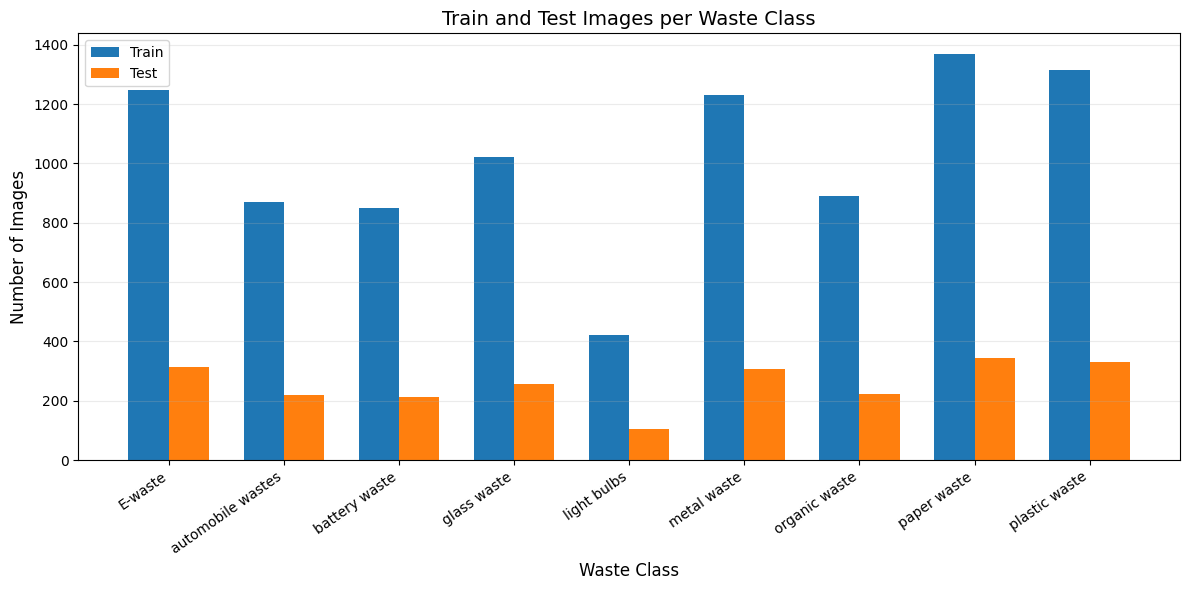

In [ ]:
x = np.arange(len(classes))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(x - width/2, train_counts, width, label="Train")
plt.bar(x + width/2, test_counts, width, label="Test")

plt.xlabel("Waste Class", fontsize=12)
plt.ylabel("Number of Images", fontsize=12)
plt.title("Train and Test Images per Waste Class", fontsize=14)

plt.xticks(x, classes, rotation=35, ha="right")
plt.grid(axis="y", alpha=0.25)
plt.legend(fontsize=10)

plt.tight_layout()
plt.savefig("train_test_images_per_class.png", dpi=300, bbox_inches="tight")
plt.show()

In [5]:
# Class definitions

RECYCLABLE_CLASSES = [
    "paper waste", "plastic waste", "glass waste",
    "metal waste", "E-waste", "battery waste"
]
UNRECYCLABLE_CLASSES = [
    "organic waste", "light bulbs", "automobile wastes"
]

source_train = "/content/wastes/train"
source_test  = "/content/wastes/test"
target_train = "/content/recycle_dataset/train"
target_test  = "/content/recycle_dataset/test"

for split, src in [("train", source_train), ("test", source_test)]:
    found = set(os.listdir(src))
    expected = set(RECYCLABLE_CLASSES + UNRECYCLABLE_CLASSES)
    missing = expected - found
    if missing:
        print(f" Missing in {split}: {missing}")
    else:
        print(f" All expected classes found in {split}.")

print("\nActual folders in train:", sorted(os.listdir(source_train)))

 All expected classes found in train.
 All expected classes found in test.

Actual folders in train: ['E-waste', 'automobile wastes', 'battery waste', 'glass waste', 'light bulbs', 'metal waste', 'organic waste', 'paper waste', 'plastic waste']


In [6]:
# Move images into recyclable / unrecyclable

def build_binary_dataset(source_dir, target_dir):
    os.makedirs(os.path.join(target_dir, "recyclable"),   exist_ok=True)
    os.makedirs(os.path.join(target_dir, "unrecyclable"), exist_ok=True)

    count = {"recyclable": 0, "unrecyclable": 0}

    for cls in RECYCLABLE_CLASSES:
        src = os.path.join(source_dir, cls)
        if not os.path.exists(src):
            print(f"   Skipping missing folder: {cls}")
            continue
        dst = os.path.join(target_dir, "recyclable")
        for img in os.listdir(src):
            shutil.copy(os.path.join(src, img), dst)
            count["recyclable"] += 1

    for cls in UNRECYCLABLE_CLASSES:
        src = os.path.join(source_dir, cls)
        if not os.path.exists(src):
            print(f"  Skipping missing folder: {cls}")
            continue
        dst = os.path.join(target_dir, "unrecyclable")
        for img in os.listdir(src):
            shutil.copy(os.path.join(src, img), dst)
            count["unrecyclable"] += 1

    return count

train_count = build_binary_dataset(source_train, target_train)
test_count  = build_binary_dataset(source_test,  target_test)

print(f"\nTrain → {train_count}")
print(f"Test  → {test_count}")

total = train_count["recyclable"] + train_count["unrecyclable"]
imbalance_ratio = train_count["recyclable"] / max(train_count["unrecyclable"], 1)
print(f"\nClass imbalance ratio (recyclable/unrecyclable): {imbalance_ratio:.2f}")


Train → {'recyclable': 7034, 'unrecyclable': 2180}
Test  → {'recyclable': 1762, 'unrecyclable': 546}

Class imbalance ratio (recyclable/unrecyclable): 3.23


## 3️⃣ Data Loading & Verification

In [7]:
IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
SEED       = 42

train_ds = tf.keras.utils.image_dataset_from_directory(
    target_train,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    target_test,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False  # Keep order for evaluation
)

CLASS_NAMES = train_ds.class_names
print("Class names (index 0, 1):", CLASS_NAMES)


RECYCLABLE_IDX   = CLASS_NAMES.index("recyclable")
UNRECYCLABLE_IDX = CLASS_NAMES.index("unrecyclable")
print(f"\nRecyclable index: {RECYCLABLE_IDX} | Unrecyclable index: {UNRECYCLABLE_IDX}")

Found 9214 files belonging to 2 classes.
Found 2308 files belonging to 2 classes.
Class names (index 0, 1): ['recyclable', 'unrecyclable']

Recyclable index: 0 | Unrecyclable index: 1


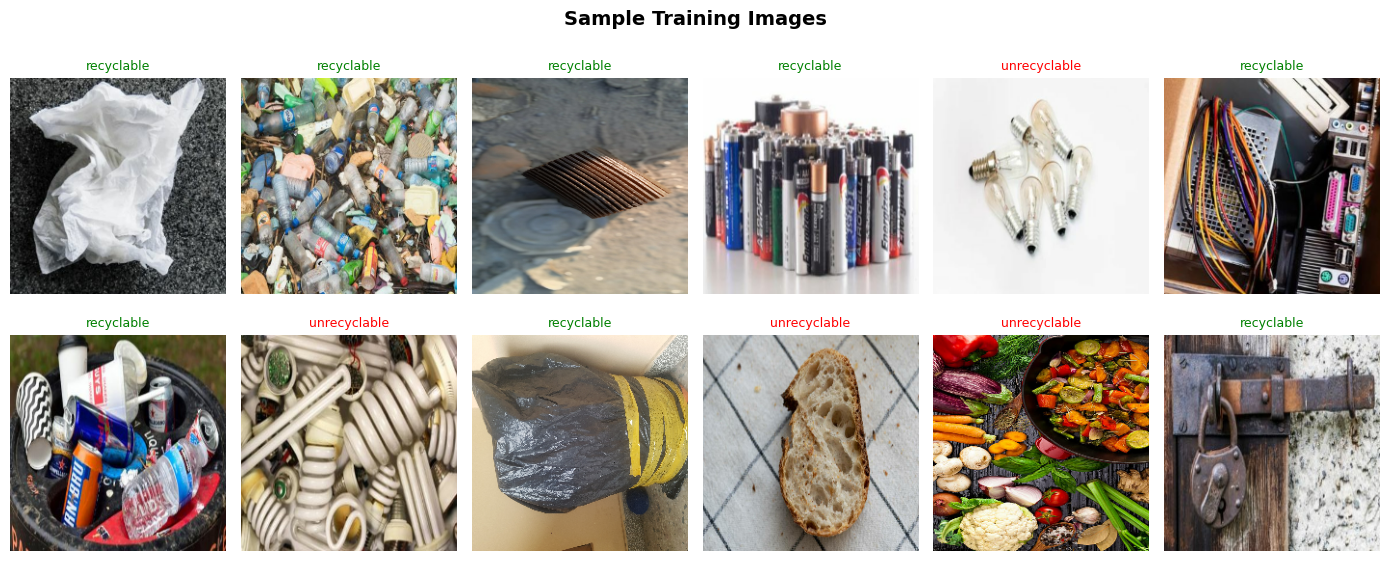

In [8]:
# Visualise sample images
plt.figure(figsize=(14, 6))
for images, labels in train_ds.take(1):
    for i in range(min(12, len(images))):
        ax = plt.subplot(2, 6, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        label_name = CLASS_NAMES[labels[i].numpy()]
        color = "green" if label_name == "recyclable" else "red"
        plt.title(label_name, color=color, fontsize=9)
        plt.axis("off")
plt.suptitle("Sample Training Images", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [9]:
# Performance optimisation
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test_ds  = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 4️⃣ Model Architecture

In [10]:
# Data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")

# Base model
base_model = EfficientNetB0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False  # Freeze for initial training

# Full model
inputs = tf.keras.Input(shape=(224, 224, 3), name="input_image")
x = data_augmentation(inputs)
# EfficientNetB0 expects values in [0, 255]; its internal preprocessing handles normalisation
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D(name="gap")(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu", name="dense_256")(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(64, activation="relu", name="dense_64")(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(1, activation="sigmoid", name="output")(x)

model = tf.keras.Model(inputs, outputs, name="RecyclabilityClassifier")
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "RecyclabilityClassifier"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_image (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ gap (GlobalAveragePooling2D)    │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_256 (Dense)               │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_64 (Dense)                │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,399,140 (16.78 MB)

 Trainable params: 347,009 (1.32 MB)

 Non-trainable params: 4,052,131 (15.46 MB)

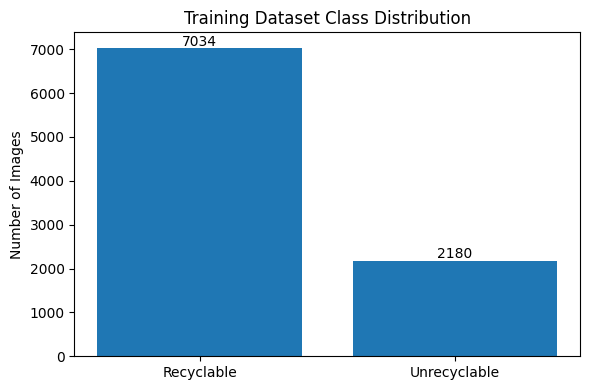

In [11]:
import matplotlib.pyplot as plt

classes = ['Recyclable', 'Unrecyclable']
counts = [
    train_count['recyclable'],
    train_count['unrecyclable']
]

plt.figure(figsize=(6,4))
bars = plt.bar(classes, counts)

plt.title('Training Dataset Class Distribution')
plt.ylabel('Number of Images')

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 50,
        f'{int(bar.get_height())}',
        ha='center'
    )

plt.tight_layout()
plt.show()

In [13]:
#  Class weights (handles imbalance)
n_recyclable   = train_count["recyclable"]
n_unrecyclable = train_count["unrecyclable"]
n_total        = n_recyclable + n_unrecyclable

weight_recyclable   = n_total / (2 * n_recyclable)
weight_unrecyclable = n_total / (2 * n_unrecyclable)

class_weight = {
    RECYCLABLE_IDX:   weight_recyclable,
    UNRECYCLABLE_IDX: weight_unrecyclable
}
print("Class weights:", class_weight)

Class weights: {0: 0.654961615012795, 1: 2.113302752293578}


## 5️⃣ Phase 1 — Train with Frozen Base

In [14]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

callbacks_phase1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=4, restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss", factor=0.5, patience=2, min_lr=1e-6, verbose=1
    )
]

history1 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=20,
    class_weight=class_weight,
    callbacks=callbacks_phase1
)

Epoch 1/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 291s 396ms/step - accuracy: 0.8304 - loss: 0.3795 - precision: 0.6025 - recall: 0.8321 - val_accuracy: 0.9116 - val_loss: 0.2066 - val_precision: 0.7664 - val_recall: 0.9011 - learning_rate: 0.0010
Epoch 2/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 28s 96ms/step - accuracy: 0.8909 - loss: 0.2670 - precision: 0.7159 - recall: 0.8936 - val_accuracy: 0.9103 - val_loss: 0.2223 - val_precision: 0.7474 - val_recall: 0.9377 - learning_rate: 0.0010
Epoch 3/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 27s 94ms/step - accuracy: 0.9048 - loss: 0.2261 - precision: 0.7461 - recall: 0.9060 - val_accuracy: 0.9198 - val_loss: 0.2027 - val_precision: 0.7807 - val_recall: 0.9194 - learning_rate: 0.0010
Epoch 4/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 27s 93ms/step - accuracy: 0.9216 - loss: 0.1883 - precision: 0.7828 - recall: 0.9257 - val_accuracy: 0.9246 - val_loss: 0.2011 - val_precision: 0.7906 - val_recall: 0.9267 - learning_rate: 0.0010
Epoch 5/20
288/288 ━━━━━━━━━━━━━━━━━━━━ 42s 95ms/step 

## 6️⃣ Phase 2 — Fine-Tuning (Unfreeze Top Layers)

In [15]:
# Unfreeze only the top 30 layers of EfficientNetB0
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable EfficientNet layers: {trainable_count} / {len(base_model.layers)}")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

callbacks_phase2 = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=5, restore_best_weights=True
    ),
    tf.keras.callbacks.ModelCheckpoint(
        "recyclability_best.keras",
        monitor="val_accuracy", save_best_only=True, verbose=1
    )
]

history2 = model.fit(
    train_ds,
    validation_data=test_ds,
    epochs=15,
    class_weight=class_weight,
    callbacks=callbacks_phase2
)

Trainable EfficientNet layers: 30 / 238
Epoch 1/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.9329 - loss: 0.2178 - precision: 0.8378 - recall: 0.8981
Epoch 1: val_accuracy improved from None to 0.92721, saving model to recyclability_best.keras

Epoch 1: finished saving model to recyclability_best.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 51s 125ms/step - accuracy: 0.9324 - loss: 0.1945 - precision: 0.8275 - recall: 0.9023 - val_accuracy: 0.9272 - val_loss: 0.1971 - val_precision: 0.8010 - val_recall: 0.9212
Epoch 2/15
288/288 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step - accuracy: 0.9333 - loss: 0.1611 - precision: 0.8082 - recall: 0.9371
Epoch 2: val_accuracy improved from 0.92721 to 0.92808, saving model to recyclability_best.keras

Epoch 2: finished saving model to recyclability_best.keras
288/288 ━━━━━━━━━━━━━━━━━━━━ 36s 124ms/step - accuracy: 0.9334 - loss: 0.1667 - precision: 0.8135 - recall: 0.9321 - val_accuracy: 0.9281 - val_loss: 0.1948 - val_precision: 0.8055 - val_recall: 0.9

## 7️⃣ Training History Plots

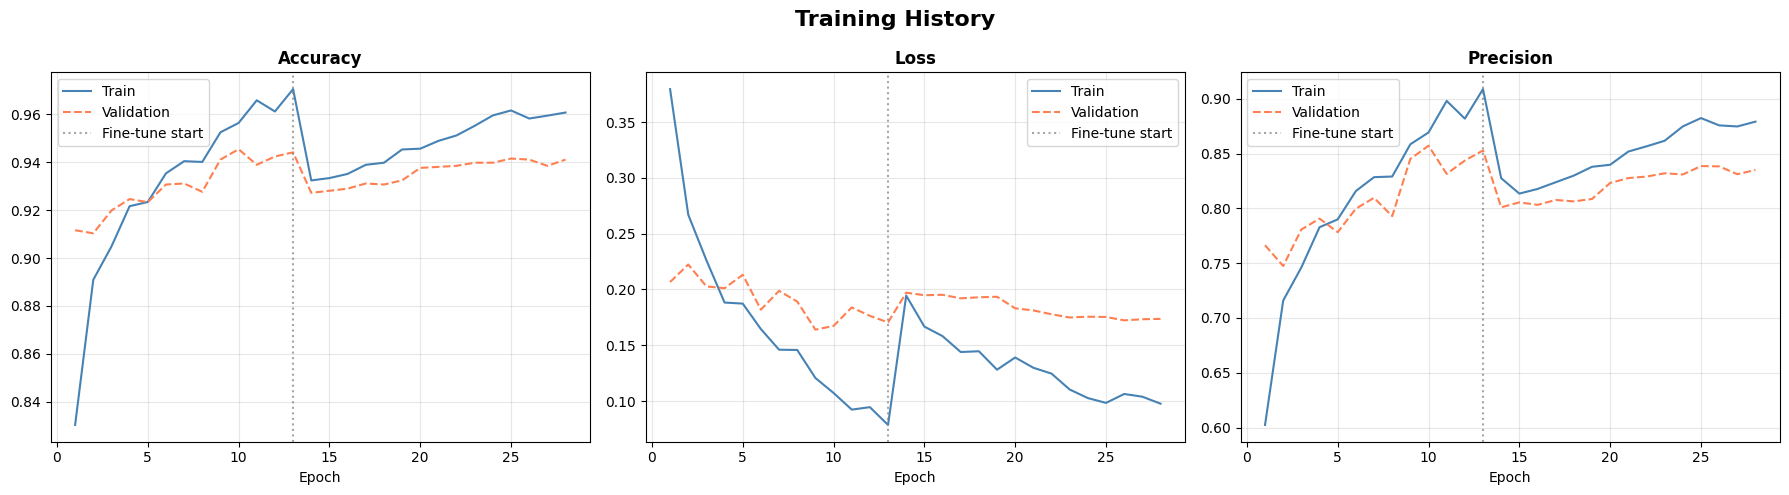

In [16]:
def merge_histories(h1, h2):
    merged = {}
    for k in h1.history:
        merged[k] = h1.history[k] + h2.history.get(k, [])
    return merged

history = merge_histories(history1, history2)
epochs  = range(1, len(history["accuracy"]) + 1)
phase1_end = len(history1.history["accuracy"])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Training History", fontsize=16, fontweight="bold")

metrics = [
    ("accuracy",  "Accuracy"),
    ("loss",      "Loss"),
    ("precision", "Precision")
]

for ax, (metric, title) in zip(axes, metrics):
    ax.plot(epochs, history[metric],          label="Train",      color="steelblue")
    ax.plot(epochs, history[f"val_{metric}"], label="Validation", color="coral", linestyle="--")
    ax.axvline(phase1_end, color="gray", linestyle=":", alpha=0.7, label="Fine-tune start")
    ax.set_title(title, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("training_history.png", dpi=150, bbox_inches="tight")
plt.show()

## 8️⃣ Evaluation — Metrics & Confusion Matrix

In [17]:
# Collect all predictions
y_true, y_pred_prob = [], []

for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred_prob.extend(preds.flatten())

y_true      = np.array(y_true)
y_pred_prob = np.array(y_pred_prob)

#  0 = recyclable, 1 = unrecyclable  (r < u)
# So sigmoid > 0.5 → class 1 → unrecyclable
THRESHOLD = 0.5
y_pred = (y_pred_prob > THRESHOLD).astype(int)

print(f"Class names: {CLASS_NAMES}")
print(f"Recyclable index: {RECYCLABLE_IDX}, Unrecyclable index: {UNRECYCLABLE_IDX}")
print(f"\nTotal test samples: {len(y_true)}")
print(f"True recyclable:    {(y_true == RECYCLABLE_IDX).sum()}")
print(f"True unrecyclable:  {(y_true == UNRECYCLABLE_IDX).sum()}")

Class names: ['recyclable', 'unrecyclable']
Recyclable index: 0, Unrecyclable index: 1

Total test samples: 2308
True recyclable:    1762
True unrecyclable:  546


In [18]:
#  Classification report
print("\n" + "="*55)
print("         CLASSIFICATION REPORT")
print("="*55)
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

acc = (y_pred == y_true).mean()
prec = precision_score(y_true, y_pred)
rec  = recall_score(y_true, y_pred)
f1   = f1_score(y_true, y_pred)

print(f"Overall Accuracy : {acc:.4f} ({acc*100:.2f}%)")
print(f"Precision        : {prec:.4f}")
print(f"Recall           : {rec:.4f}")
print(f"F1 Score         : {f1:.4f}")


         CLASSIFICATION REPORT
              precision    recall  f1-score   support

  recyclable       0.98      0.94      0.96      1762
unrecyclable       0.84      0.93      0.88       546

    accuracy                           0.94      2308
   macro avg       0.91      0.94      0.92      2308
weighted avg       0.94      0.94      0.94      2308

Overall Accuracy : 0.9411 (94.11%)
Precision        : 0.8383
Recall           : 0.9304
F1 Score         : 0.8819


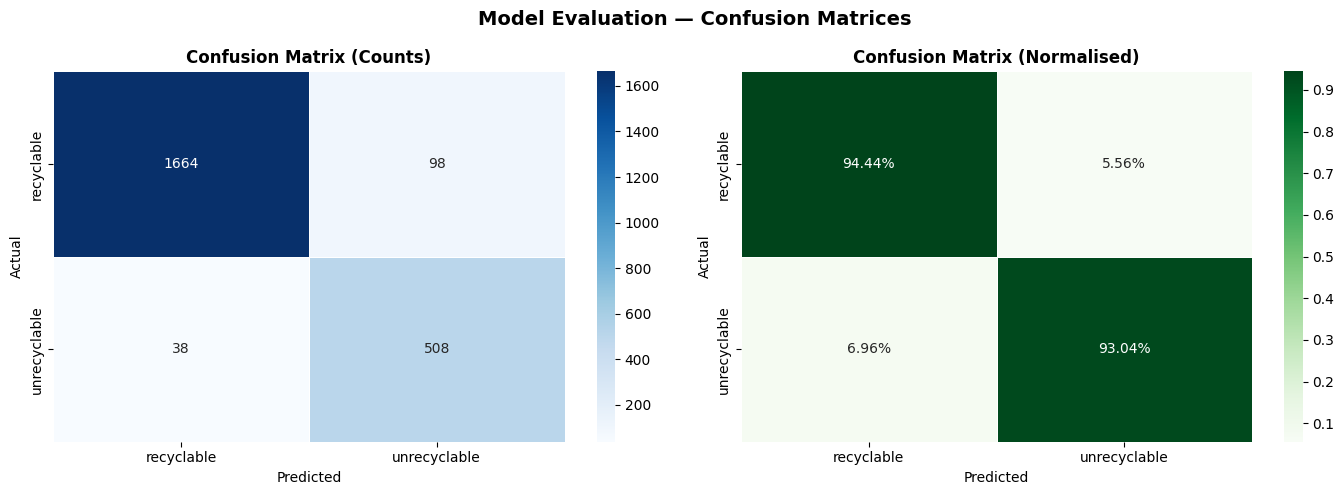

In [19]:
#  Confusion matrix
cm = confusion_matrix(y_true, y_pred)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(
    cm, annot=True, fmt="d",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    cmap="Blues", ax=axes[0], linewidths=0.5
)
axes[0].set_title("Confusion Matrix (Counts)", fontweight="bold")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

# Normalised
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(
    cm_norm, annot=True, fmt=".2%",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    cmap="Greens", ax=axes[1], linewidths=0.5
)
axes[1].set_title("Confusion Matrix (Normalised)", fontweight="bold")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.suptitle("Model Evaluation — Confusion Matrices", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

Optimal threshold: 0.4882
AUC: 0.9826


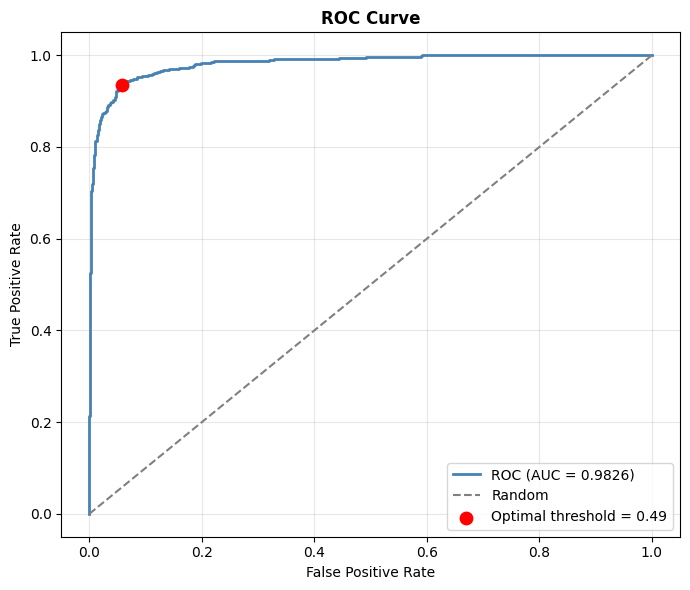

In [20]:
# ROC Curve
from sklearn.metrics import roc_curve, auc

fpr, tpr, thresholds = roc_curve(y_true, y_pred_prob)
roc_auc = auc(fpr, tpr)

optimal_idx = np.argmax(tpr - fpr)
optimal_threshold = thresholds[optimal_idx]
print(f"Optimal threshold: {optimal_threshold:.4f}")
print(f"AUC: {roc_auc:.4f}")

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC (AUC = {roc_auc:.4f})")
plt.plot([0, 1], [0, 1], color="gray", linestyle="--", label="Random")
plt.scatter(fpr[optimal_idx], tpr[optimal_idx],
            color="red", s=80, zorder=5,
            label=f"Optimal threshold = {optimal_threshold:.2f}")
plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
plt.title("ROC Curve", fontweight="bold")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("roc_curve.png", dpi=150, bbox_inches="tight")
plt.show()

## 9️⃣ Grad-CAM Visualisation

Sample images: ['/content/wastes/test/E-waste/e-waste (1).jpg', '/content/wastes/test/glass waste/glass waste (1).jpg', '/content/wastes/test/plastic waste/plastic waste (1).jpg', '/content/wastes/test/organic waste/organic waste (1).jpeg']


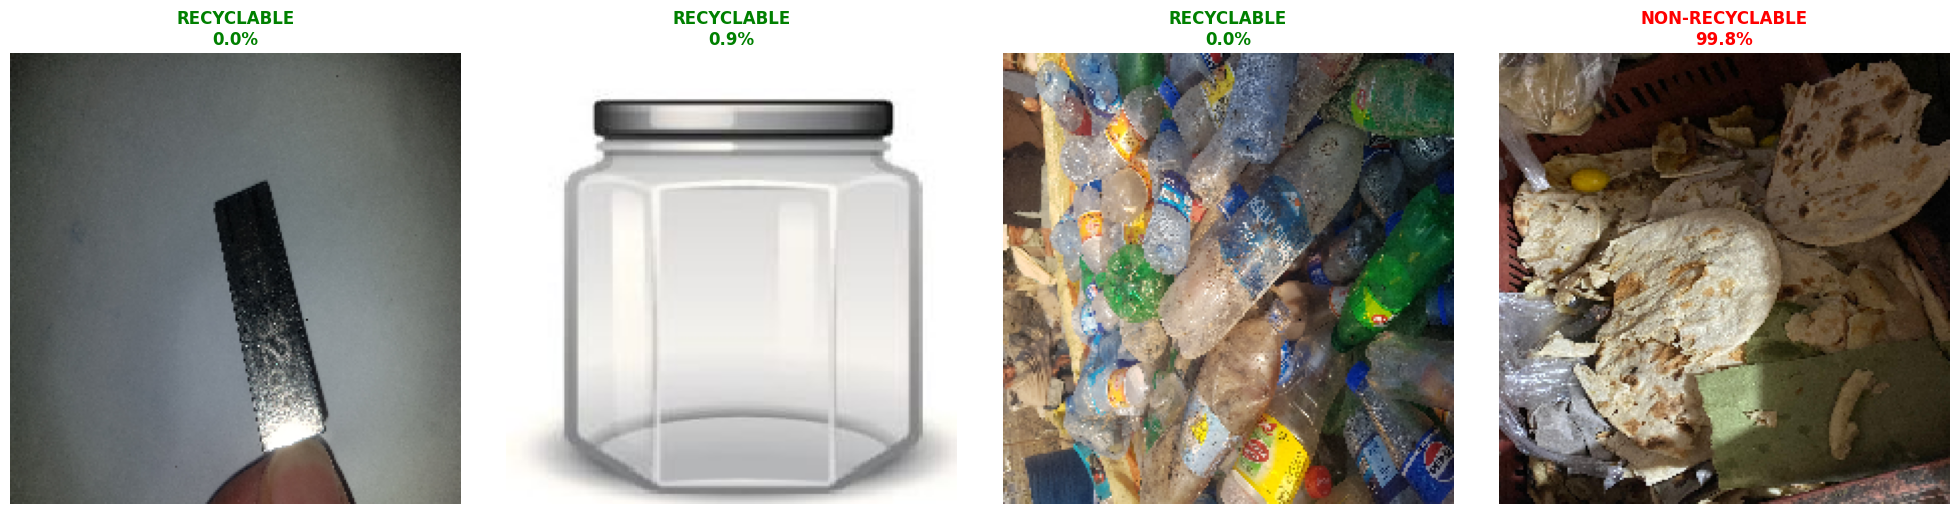

In [28]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as keras_image

IMG_SIZE = (224, 224)
THRESHOLD = 0.5
CLASS_NAMES = ["recyclable", "non-recyclable"]

def get_first_image(folder):
    if not os.path.exists(folder):
        return None
    for f in sorted(os.listdir(folder)):
        if f.lower().endswith((".jpg", ".jpeg", ".png")):
            return os.path.join(folder, f)
    return None

sample_images = list(filter(None, [
    get_first_image("/content/wastes/test/E-waste"),
    get_first_image("/content/wastes/test/glass waste"),
    get_first_image("/content/wastes/test/plastic waste"),
    get_first_image("/content/wastes/test/organic waste"),
]))

print("Sample images:", sample_images)

# ================== DISPLAY ==================
fig, axes = plt.subplots(1, len(sample_images), figsize=(5 * len(sample_images), 5))

if len(sample_images) == 1:
    axes = [axes]

for ax, img_path in zip(axes, sample_images):
    img = keras_image.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras_image.img_to_array(img)

    img_input = np.expand_dims(img_array, axis=0)
    img_input = tf.keras.applications.efficientnet.preprocess_input(img_input)

    pred_prob = model.predict(img_input, verbose=0)[0][0]
    pred_class = int(pred_prob > THRESHOLD)
    label = CLASS_NAMES[pred_class]

    color = "green" if label == "recyclable" else "red"

    ax.imshow(img)
    ax.set_title(f"{label.upper()}\n{pred_prob*100:.1f}%", color=color, fontweight="bold")
    ax.axis("off")

plt.tight_layout()
plt.show()

## 🔟 Prediction Function (Production-Ready)

In [36]:
import tensorflow as tf
import numpy as np
import os
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing import image as keras_image

def predict_recyclability(img_path, model=model, threshold=THRESHOLD,
                         show_gradcam=False, verbose=True):


    assert os.path.exists(img_path), f"File not found: {img_path}"

    img = keras_image.load_img(img_path, target_size=IMG_SIZE)
    img_array = keras_image.img_to_array(img)

    img_input = np.expand_dims(img_array, axis=0)
    img_input = tf.keras.applications.efficientnet.preprocess_input(img_input)
    raw_prob = float(model.predict(img_input, verbose=0)[0][0])
    pred_class = int(raw_prob > threshold)
    label = CLASS_NAMES[pred_class]
    confidence = raw_prob if pred_class == UNRECYCLABLE_IDX else (1 - raw_prob)

    if verbose:
        icon = "♻️" if label == "recyclable" else "🚫"
        print(f"{icon}  Prediction : {label.upper()}")
        print(f"   Confidence : {confidence*100:.2f}%")
        print(f"   Raw prob   : {raw_prob:.4f} (threshold={threshold})")


    fig, ax = plt.subplots(figsize=(4, 4))
    color = "green" if label == "recyclable" else "red"

    ax.imshow(img)
    ax.set_title(f"{label.upper()} — {confidence*100:.1f}%",
                 color=color, fontweight="bold")
    ax.axis("off")

    plt.tight_layout()
    plt.show()

    return {"label": label, "confidence": confidence, "raw_prob": raw_prob}


🚫  Prediction : UNRECYCLABLE
   Confidence : 100.00%
   Raw prob   : 1.0000 (threshold=0.5)


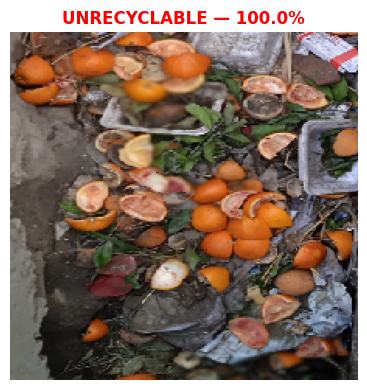

{'label': 'unrecyclable', 'confidence': 0.9999992847442627, 'raw_prob': 0.9999992847442627}


In [35]:
# Quick test
result = predict_recyclability(
    "/content/wastes/test/organic waste/organic waste (100).png",
    show_gradcam=True
)
print(result)
/content/wastes/test/plastic waste

♻️  Prediction : RECYCLABLE
   Confidence : 99.32%
   Raw prob   : 0.0068 (threshold=0.5)


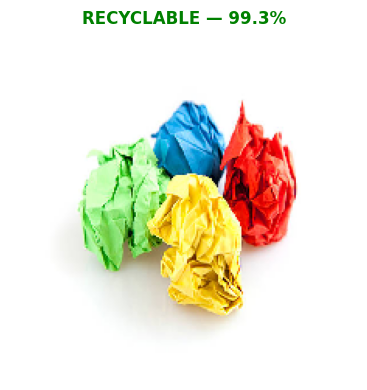

{'label': 'recyclable', 'confidence': 0.9932236219756305, 'raw_prob': 0.006776378024369478}


In [37]:
result = predict_recyclability(
    "/content/wastes/test/paper waste/paper waste (105).jpg",
    show_gradcam=True
)
print(result)

♻️  Prediction : RECYCLABLE
   Confidence : 99.22%
   Raw prob   : 0.0078 (threshold=0.5)


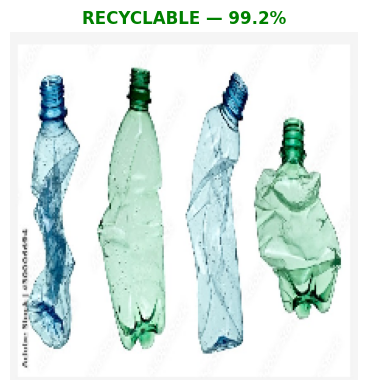

{'label': 'recyclable', 'confidence': 0.9921713545918465, 'raw_prob': 0.007828645408153534}


In [ ]:
result = predict_recyclability(
    "/content/WhatsApp Image 2026-03-23 at 7.22.10 AM.jpeg",
    show_gradcam=True
)
print(result)

## 1️⃣1️⃣ Save & Download Model

In [41]:

model.save("recyclability_model_v2.keras")
import json
metadata = {
    "class_names":       CLASS_NAMES,
    "recyclable_idx":    RECYCLABLE_IDX,
    "unrecyclable_idx":  UNRECYCLABLE_IDX,
    "threshold":         THRESHOLD,
    "img_size":          list(IMG_SIZE),
    "recyclable_classes":   RECYCLABLE_CLASSES,
    "unrecyclable_classes": UNRECYCLABLE_CLASSES
}
with open("model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(" Model saved!")
print("Files:", [f for f in os.listdir(".") if f.startswith("recyclability") or f == "model_metadata.json"])

 Model saved!
Files: ['recyclability_best.keras', 'model_metadata.json', 'recyclability_model_v2.keras']


In [42]:
from google.colab import files
files.download("recyclability_model_v2.keras")
files.download("model_metadata.json")
files.download("training_history.png")
files.download("confusion_matrix.png")
files.download("roc_curve.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>